# Loading

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
# from pprint import pprint
from datetime import timedelta, datetime
import gnss_lib_py as glp
# from gnss_lib_py.utils.ephemeris_downloader import load_ephemeris
from astropy.time import Time # datetime to TAI
import plotly.graph_objects as go

# from dataclasses import dataclass
# from pymap3d import eci2ecef
# from src.conversions import eci_to_ecef
from astropy.coordinates import get_body, ITRS
from lunarsky import MCMF
from astropy import units as u

from src.lugre_parser import get_unique_timestamps, lugre_parser, get_unique_times, gps_seconds_to_gps_weeks

plt.rcdefaults()

In [153]:
# import pylupnt as pnt


## Importing Data

In [154]:
data_path = Path().joinpath("LuGRE Mission Data/L0/TLM/")
set_ids = get_unique_timestamps(data_path) # get all unique timestamps in the directory

# shrink set_ids to the ones on lunar surface
surface_ids = [set_id for set_id in set_ids if "_S_" in set_id]
print(len(surface_ids), "surface data sets found")


lugre_df = [lugre_parser(data_path, set_id) for set_id in surface_ids]

7 surface data sets found


/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Users/magi-nerv/Space-Specifically/Stanford/AA-272-GPS-Final/src/lugre_parser.py:62: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead

/Use

In [155]:
print([lugre_df[0][i].columns for i in lugre_df[0].keys()])

[Index(['date', 'time', 'duration', 'phase', 'opnumber', 'index'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'signalId', 'svid', 'doppler',
       'codePhase', 'acfCorr', 'noiseFloor', 'acqMode', 'CN0'],
      dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'appName', 'wn', 'tow', 'decimals',
       'nSat', 'posX', 'posY', 'posZ', 'velX', 'velY', 'velZ', 'posStd',
       'velStd', 'timStd', 'clockBias', 'clockDrift', 'ggto', 'GDOP', 'PDOP',
       'HDOP', 'VDOP', 'TDOP'],
      dtype='object'), Index(['rxTime', 'signal', 'svId', 'Toe', 'Toc', 'iodNav', 'iodE', 'iodC'], dtype='object'), Index(['Receiver Time [s]', 'Clock Bias [m]', 'ClockDrift [m/s]'], dtype='object'), Index(['senderId', 'messageType', 'rxTime', 'measures', 'svid', 'prRaw', 'cn0',
       'signalId', 'fdRaw', 'accDoppler', 'fdRateRaw'],
      dtype='object')]


In [156]:
dataset_id = 1
dataset = lugre_df[dataset_id]
nav = dataset["nav"]

# nav = pd.concat([df["nav"] for df in lugre_df])

# rover ECEF in meters -> convert to km
rx_ecef_km = nav[["posX", "posY", "posZ"]].to_numpy() / 1000.0

## Time Transforms

In [157]:
gps_time_s = nav["rxTime"].to_numpy()
utc_times = [ glp.gps_millis_to_datetime(t*1000) for t in gps_time_s ]

### Moon

In [158]:
# Time for Astropy
t_ast = Time(utc_times, scale='utc')

# GCRS to ITRS (ECEF)
moon_gcrs = get_body("moon", t_ast)
moon_itrs = moon_gcrs.transform_to(ITRS(obstime=t_ast))

# Extract as km for plotting
moon_ecef_km = np.column_stack([
    moon_itrs.x.to(u.km).value,
    moon_itrs.y.to(u.km).value,
    moon_itrs.z.to(u.km).value
])


# Initial Plots

(1500.0, 3500.0)

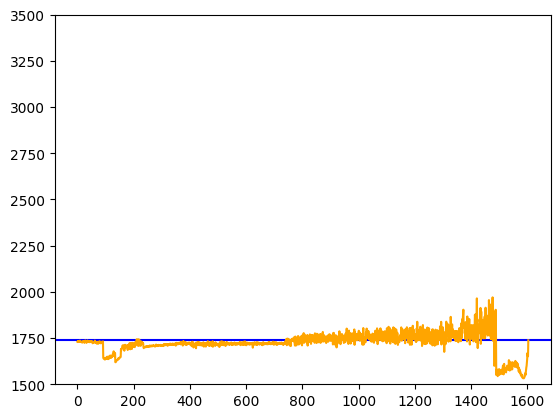

In [159]:
# Moon radius check
distances = rx_ecef_km - moon_ecef_km
distances = np.apply_along_axis(np.linalg.norm, 1, distances)
# print(distances)
plt.axhline( 1.7374e3, color='b')
plt.plot(distances, color='orange')
plt.ylim(1.5e3,3.5e3)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


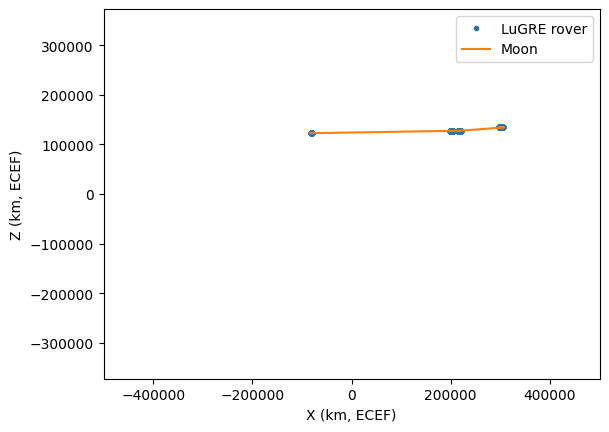

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


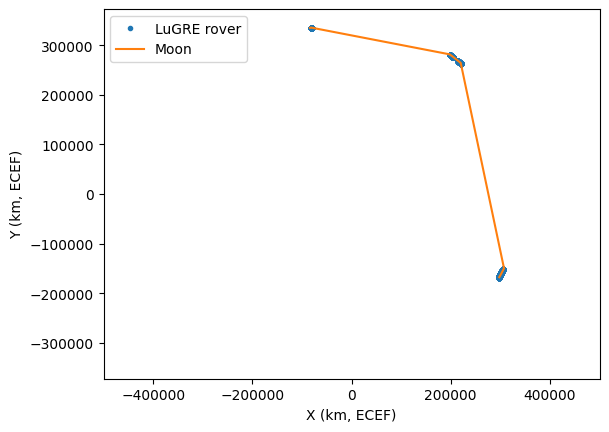

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


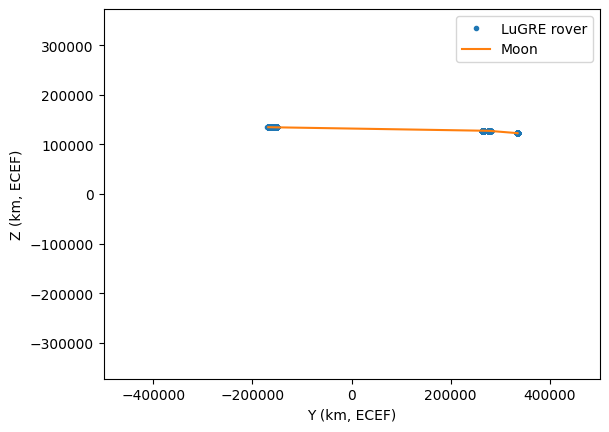

In [160]:
plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,2], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,2], '-', label="Moon")
plt.axis('equal')
plt.legend()
plt.xlabel("X (km, ECEF)")
plt.ylabel("Z (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.show()

plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,1], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,1], '-', label="Moon")
plt.axis('equal')
plt.legend()
plt.xlabel("X (km, ECEF)")
plt.ylabel("Y (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.show()

plt.figure()
plt.plot(rx_ecef_km[:,1], rx_ecef_km[:,2], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,1], moon_ecef_km[:,2], '-', label="Moon")
plt.axis('equal')
plt.legend()
plt.xlabel("Y (km, ECEF)")
plt.ylabel("Z (km, ECEF)")
plt.xlim(-5e5, 5e5)
plt.ylim(-5e5, 5e5)
plt.show()

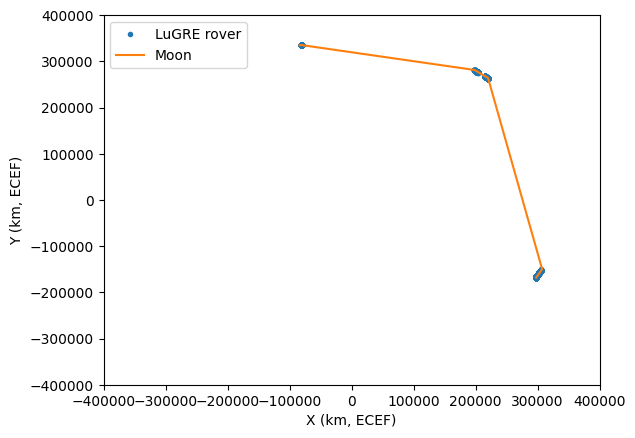

In [161]:
plt.figure()
plt.plot(rx_ecef_km[:,0], rx_ecef_km[:,1], '.', label="LuGRE rover")
plt.plot(moon_ecef_km[:,0], moon_ecef_km[:,1], '-', label="Moon")
# plt.axis('equal')
plt.legend()
plt.xlabel("X (km, ECEF)")
plt.ylabel("Y (km, ECEF)")
plt.xlim(-4e5, 4e5)
plt.ylim(-4e5, 4e5)
plt.show()

In [ ]:

# # Create a 3D scatter plot
# fig = go.Figure(data=[go.Scatter3d(
#     x=rx_ecef_km[0],
#     y=rx_ecef_km[1],
#     z=rx_ecef_km[2],
#     mode='markers',  # Display points as markers
#     marker=dict(
#         size=5,
#         color='red',  # Color points based on their z-value
#         colorscale='Viridis',  # Choose a colorscale
#         opacity=0.8
#     )
# ),
# go.Scatter3d(
#     x=moon_ecef_km[0],
#     y=moon_ecef_km[1],
#     z=moon_ecef_km[2],
#     mode='markers',  # Display points as markers
#     marker=dict(
#         size=5,
#         color='blue',  # Color points based on their z-value
#         colorscale='Viridis',  # Choose a colorscale
#         opacity=0.8
#     )
# )

# ])

# # Customize layout (optional)
# fig.update_layout(
#     title='3D Scatter Plot of Random Points',
#     scene=dict(
#         xaxis_title='X Axis',
#         yaxis_title='Y Axis',
#         zaxis_title='Z Axis'
#     ),
#     xaxis=dict(
#         range=[-5e5, 5e5],
#         # Other x-axis properties can be set here as well
#     ),
#     yaxis=dict(
#         range=[-5e5, 5e5],
#         # Other x-axis properties can be set here as well
#     )
# )

# # Display the plot
# fig.show()

# More moon

In [163]:
def rover_ecef_to_mcmf(rx_ecef_km, t_ast):
    # Convert to meters (lunarsky expects meters)
    coords_m = rx_ecef_km * u.km.to(u.m)

    # Split components
    x = coords_m[:,0] * u.m
    y = coords_m[:,1] * u.m
    z = coords_m[:,2] * u.m


    # Build vectorized ITRS object
    itrs = ITRS(x=x, y=y, z=z, obstime=t_ast)

    # Single transform step (fastest possible)
    mcmf = itrs.transform_to(MCMF(obstime=t_ast))

    # Return km array
    return np.column_stack([
        mcmf.x.to(u.km).value,
        mcmf.y.to(u.km).value,
        mcmf.z.to(u.km).value
    ])

In [164]:
rover_itrs_obj = rover_ecef_to_mcmf(rx_ecef_km, utc_times)
# print(rover_itrs_obj)


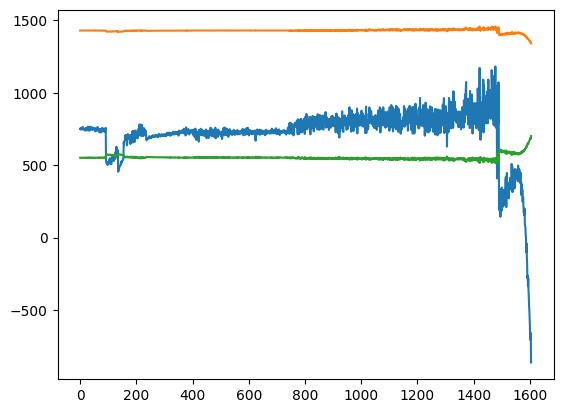

In [165]:
# rover_mcmf_km = np.array([make_itrf(x, t) for i,j in zip()])

# # Extract as km for plotting
# rover_mcmf_km = np.column_stack([
#     rover_mcmf.x.to(u.km).value,
#     rover_mcmf.y.to(u.km).value,
#     rover_mcmf.z.to(u.km).value
# ])
# print(np.shape(rover_itrs_obj))
plt.plot(rover_itrs_obj[:,0])
plt.plot(rover_itrs_obj[:,1])
plt.plot(rover_itrs_obj[:,2])
# plt.plot()
